In [35]:
import numpy as np
import matplotlib.pyplot as plt

- [0, 2.094, 4.189]
- [0, 1.571, 3.142, 4.712]
- [0.28753996 0.7719372  1.52004957 3.43165255]
  
```python
def F(z, theta_vals): 
    theta = np.random.choice(theta_vals)
    return (-0.54 * np.exp(5.91j) / z - 0.54 * np.exp(3.5j) * complex(z).conjugate() + 1.71 - 0.67j) * np.exp(1j * theta)
```

In [36]:
def F(z): 
    n = np.random.randint(0, 3)
    return {
        0: lambda z: -1 / z, 
        1: lambda z: z + 1, 
        2: lambda z: z - 1
    }[n](z)

In [37]:
with open('data.csv', 'w') as f:
    batch_counter = 0
    z = 0.5 + 0.5j
    for i in range(1_000_000):
        z = F(z)
        w = (z - 1j) / (z + 1j)
        f.write(f"{w.real:.6f},{w.imag:.6f}\n")
        
        batch_counter += 1

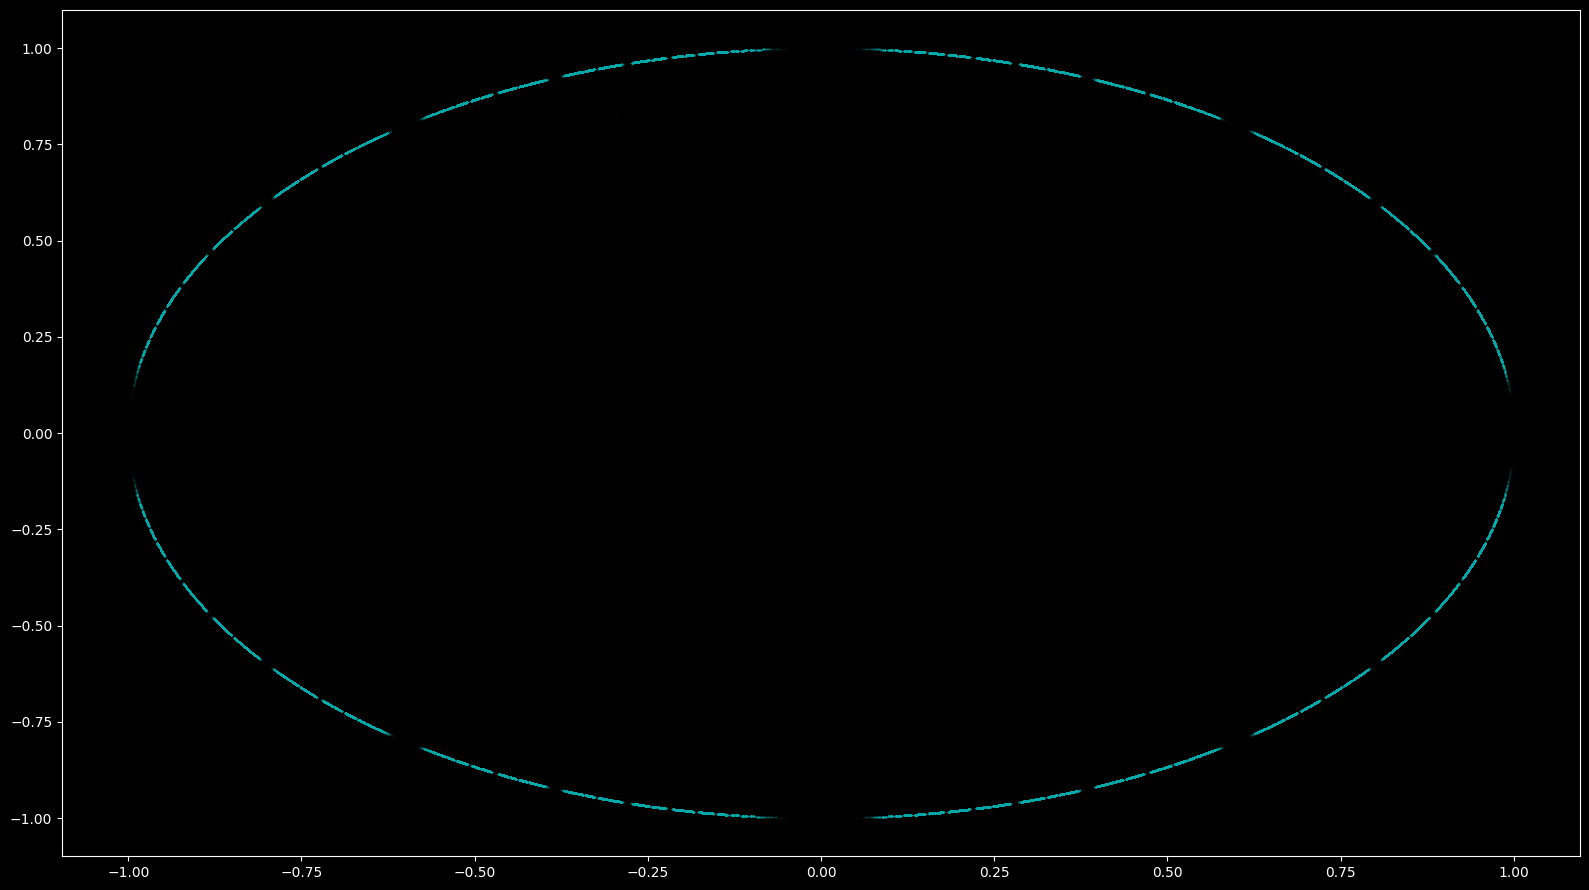

In [38]:
plt.figure(figsize=(16, 9))

color = 'cyan'
edgecolors = 'cyan'

alpha = 0.03
s = 0.1

try:
    data = np.loadtxt('data.csv', delimiter=',')
    if len(data) > 0:
        real_parts = data[:, 0]
        imag_parts = data[:, 1]

        plt.scatter(real_parts, imag_parts, color=color, alpha=alpha, s=s, edgecolors=edgecolors)
        
except MemoryError:
    chunk_size = 500_000
    all_data = []
    
    with open('data.csv', 'r') as f:
        chunk = []
        for line in f:
            parts = line.strip().split(',')
            if len(parts) == 2:
                chunk.append([float(parts[0]), float(parts[1])])
            
            if len(chunk) >= chunk_size:
                chunk_arr = np.array(chunk)
                plt.scatter(chunk_arr[:, 0], chunk_arr[:, 1], color=color, alpha=alpha, s=s, edgecolors=edgecolors)
                chunk = []
        
        if chunk:
            chunk_arr = np.array(chunk)
            plt.scatter(chunk_arr[:, 0], chunk_arr[:, 1], color=color, alpha=alpha, s=s, edgecolors=edgecolors)

# plt.xlim(-0.5, 0.5)
# plt.ylim(-0.5, 0.5)

# plt.axis('off')

plt.tight_layout()
plt.savefig('output/ifs.png', dpi=200)